# AI-Based Online Gaming Player Retention Prediction Using Random Forest
## Phase 2: Data Preprocessing, Academic Retention Proxy Construction & Feature Engineering Pipeline

---
### Academic Submission Metadata & Context
- **Project Title:** AI-Based Online Gaming Player Retention Prediction Using Random Forest
- **Methodology:** CRISP-DM Framework (Phase 2: Data Preparation & Feature Engineering)
- **Target Formulation:** Documented Academic Retention Proxy derived from Behavioral Engagement
- **Leakage Safeguards:** Scikit-Learn `ColumnTransformer` & `Pipeline` Architecture
- **Partitioning:** Stratified 80/20 Train-Test Split (`random_state=42`)

---
### Critical Methodological Note on Target Formulation (For Viva Defense)
> **Academic Note:** The benchmark *Online Gaming Behavior Dataset* is a cross-sectional snapshot of player telemetry and **does not contain a true prospective longitudinal churn/retention timestamp** (e.g., return within D1, D7, or D30).
> 
> To enable supervised classification for this project, we define an operational **Retention Proxy**:
> - **`Medium` & `High` Engagement $\rightarrow$ `Retained` (`1`)**: Players with sustained activity, progression, and regular sessions who are actively retained.
> - **`Low` Engagement $\rightarrow$ `At Risk` (`0`)**: Disengaged players demonstrating minimal playtime and low session counts who are at imminent risk of churning.
> 
> **Data Leakage Prohibition:** Because `RetentionTarget` is directly constructed from `EngagementLevel`, the original `EngagementLevel` column **MUST BE EXCLUDED** from model input features $X$, along with arbitrary identifiers (`PlayerID`).


In [1]:
# ==============================================================================
# 0. ENVIRONMENT & LIBRARIES SETUP
# ==============================================================================
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn preprocessing and modeling tools
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Plotting & style configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.titlesize'] = 14

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

# Output directory for saving figures
OUTPUTS_DIR = Path("outputs")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"🐍 Python Version : {sys.version.split()[0]}")
print(f"🐼 Pandas Version : {pd.__version__}")
print(f"🔢 NumPy Version  : {np.__version__}")
print(f"📁 Outputs Dir    : {OUTPUTS_DIR.resolve()}")
print("✅ Libraries and directory structure verified.")

🐍 Python Version : 3.14.4
🐼 Pandas Version : 3.0.5
🔢 NumPy Version  : 2.4.6
📁 Outputs Dir    : /Users/mdkasifuddin/Developer/Python/Gaming Retention/outputs
✅ Libraries and directory structure verified.


### 1. Dynamic Dataset Discovery & Loading
We load the dataset using dynamic discovery to ensure complete portability across local environments and Google Colab.

In [2]:
# ==============================================================================
# 1. DATASET DISCOVERY & INGESTION
# ==============================================================================
def find_dataset(start_dir="."):
    base = Path(start_dir).resolve()
    candidates = list(base.rglob("*.csv")) + list(base.parent.rglob("*.csv"))
    valid = [p for p in candidates if not any(part.startswith('.') or 'trash' in part.lower() for part in p.parts)]
    for p in valid:
        if "online_gaming_behavior" in p.name.lower():
            return p
    if valid:
        return valid[0]
    raise FileNotFoundError("Could not find online_gaming_behavior_dataset.csv.")

dataset_path = find_dataset()
df_raw = pd.read_csv(dataset_path)

print(f"✅ Loaded: {dataset_path.name}")
print(f"Total Rows: {df_raw.shape[0]:,} | Total Columns: {df_raw.shape[1]}")

✅ Loaded: online_gaming_behavior_dataset.csv
Total Rows: 40,034 | Total Columns: 13


### 2. Operational Definition: Constructing the Retention Proxy
We formally establish the documented operational proxy:
$$\text{RetentionStatus} = \begin{cases} \text{Retained}, & \text{if } \text{EngagementLevel} \in \{\text{'Medium'}, \text{'High'}\} \\ \text{At Risk}, & \text{if } \text{EngagementLevel} = \text{'Low'} \end{cases}$$

Binary numerical target encoding:
$$\text{RetentionTarget} = \begin{cases} 1, & \text{if } \text{RetentionStatus} = \text{'Retained'} \\ 0, & \text{if } \text{RetentionStatus} = \text{'At Risk'} \end{cases}$$

In [3]:
# ==============================================================================
# 2. CONSTRUCT RETENTION PROXY (DOCUMENTED TARGET)
# ==============================================================================
df = df_raw.copy()

# Academic Retention Proxy Mapping
retention_mapping = {
    'High': 'Retained',
    'Medium': 'Retained',
    'Low': 'At Risk'
}
df['RetentionStatus'] = df['EngagementLevel'].map(retention_mapping)

# Numerical Binary Target (1 = Retained, 0 = At Risk)
df['RetentionTarget'] = df['RetentionStatus'].map({'Retained': 1, 'At Risk': 0})

print("=" * 65)
print("ACADEMIC RETENTION PROXY DISTRIBUTION")
print("=" * 65)
status_counts = df['RetentionStatus'].value_counts()
status_pcts = df['RetentionStatus'].value_counts(normalize=True) * 100

proxy_summary = pd.DataFrame({
    'Status': status_counts.index,
    'Numeric Target': [1 if s == 'Retained' else 0 for s in status_counts.index],
    'Player Count': status_counts.values,
    'Percentage (%)': status_pcts.values.round(2),
    'Operational Definition': [
        'Active/Sustained Play (Medium & High Engagement)',
        'Disengaged/High Churn Risk (Low Engagement)'
    ]
})
print(proxy_summary.to_string(index=False))

ACADEMIC RETENTION PROXY DISTRIBUTION
  Status  Numeric Target  Player Count  Percentage (%)                           Operational Definition
Retained               1         29710          74.210 Active/Sustained Play (Medium & High Engagement)
 At Risk               0         10324          25.790      Disengaged/High Churn Risk (Low Engagement)


### 3. Data Integrity & Boundary Validation
We verify that no values violate domain bounds (e.g., negative playtime, impossible age, out-of-range sessions).

In [4]:
# ==============================================================================
# 3. BOUNDARY & INVALID VALUE AUDIT
# ==============================================================================
sanity_checks = {
    'Age in [10, 100]': df['Age'].between(10, 100).all(),
    'PlayTimeHours >= 0': (df['PlayTimeHours'] >= 0).all(),
    'InGamePurchases in {0, 1}': df['InGamePurchases'].isin([0, 1]).all(),
    'SessionsPerWeek >= 0': (df['SessionsPerWeek'] >= 0).all(),
    'AvgSessionDurationMinutes > 0': (df['AvgSessionDurationMinutes'] > 0).all(),
    'PlayerLevel in [1, 100]': df['PlayerLevel'].between(1, 100).all(),
    'AchievementsUnlocked >= 0': (df['AchievementsUnlocked'] >= 0).all(),
    'Zero Missing Values': (df.isnull().sum().sum() == 0)
}

print("=" * 60)
print("DOMAIN BOUNDARY SANITY CHECKS")
print("=" * 60)
for check, passed in sanity_checks.items():
    symbol = "✅" if passed else "❌"
    print(f"{symbol} {check:<35} : {'PASSED' if passed else 'FAILED'}")

DOMAIN BOUNDARY SANITY CHECKS
✅ Age in [10, 100]                    : PASSED
✅ PlayTimeHours >= 0                  : PASSED
✅ InGamePurchases in {0, 1}           : PASSED
✅ SessionsPerWeek >= 0                : PASSED
✅ AvgSessionDurationMinutes > 0       : PASSED
✅ PlayerLevel in [1, 100]             : PASSED
✅ AchievementsUnlocked >= 0           : PASSED
✅ Zero Missing Values                 : PASSED


### 4. Feature Selection & Data Leakage Prevention
To prevent **target leakage**:
1. `PlayerID` is removed (arbitrary identifier).
2. `EngagementLevel` is removed (source variable used to derive `RetentionTarget`).
3. `RetentionStatus` and `RetentionTarget` are excluded from $X$.

In [5]:
# ==============================================================================
# 4. FEATURE SEPARATION & LEAKAGE PREVENTION
# ==============================================================================
# Columns strictly excluded from model input features
EXCLUDE_COLUMNS = ['PlayerID', 'EngagementLevel', 'RetentionStatus', 'RetentionTarget']

# Define feature matrix X and target vector y
feature_cols = [c for c in df.columns if c not in EXCLUDE_COLUMNS]
X = df[feature_cols].copy()
y = df['RetentionTarget'].copy()

# Dynamically classify remaining features by data type
categorical_features = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"🎯 Target Variable      : RetentionTarget (Binary 0/1)")
print(f"📦 Total Input Features : {X.shape[1]} features")
print(f"📊 Numerical Features   : ({len(numerical_features)}) -> {numerical_features}")
print(f"🏷️ Categorical Features : ({len(categorical_features)}) -> {categorical_features}")

🎯 Target Variable      : RetentionTarget (Binary 0/1)
📦 Total Input Features : 11 features
📊 Numerical Features   : (7) -> ['Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked']
🏷️ Categorical Features : (4) -> ['Gender', 'Location', 'GameGenre', 'GameDifficulty']


### 5. Stratified Train-Test Split (80% / 20%)
We partition the dataset into 80% training and 20% testing sets using stratified sampling (`stratify=y`) to maintain the exact class balance ($74.21\%$ vs $25.79\%$).

In [6]:
# ==============================================================================
# 5. STRATIFIED TRAIN / TEST PARTITIONING
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 65)
print("TRAIN / TEST SPLIT SUMMARY (80% Train, 20% Test, Seed=42)")
print("=" * 65)
print(f"Training Feature Matrix (X_train) : {X_train.shape[0]:,} rows × {X_train.shape[1]} columns")
print(f"Training Target Vector  (y_train) : {y_train.shape[0]:,} instances")
print(f"Testing Feature Matrix  (X_test)  : {X_test.shape[0]:,} rows × {X_test.shape[1]} columns")
print(f"Testing Target Vector   (y_test)  : {y_test.shape[0]:,} instances")
print("-" * 65)

# Verify stratified balance
train_dist = y_train.value_counts(normalize=True) * 100
test_dist = y_test.value_counts(normalize=True) * 100
split_balance = pd.DataFrame({
    'Class': ['Retained (1)', 'At Risk (0)'],
    'Train Count': y_train.value_counts().values,
    'Train Pct (%)': train_dist.values.round(2),
    'Test Count': y_test.value_counts().values,
    'Test Pct (%)': test_dist.values.round(2)
})
print(split_balance.to_string(index=False))

TRAIN / TEST SPLIT SUMMARY (80% Train, 20% Test, Seed=42)
Training Feature Matrix (X_train) : 32,027 rows × 11 columns
Training Target Vector  (y_train) : 32,027 instances
Testing Feature Matrix  (X_test)  : 8,007 rows × 11 columns
Testing Target Vector   (y_test)  : 8,007 instances
-----------------------------------------------------------------
       Class  Train Count  Train Pct (%)  Test Count  Test Pct (%)
Retained (1)        23768         74.210        5942        74.210
 At Risk (0)         8259         25.790        2065        25.790


### 6. Robust Scikit-Learn Preprocessing Pipeline (`ColumnTransformer`)
We construct a modular `ColumnTransformer` inside an scikit-learn pipeline:
- **Numerical Pipeline:**
  1. `SimpleImputer(strategy='median')`: Handles missing numerical values using median imputation.
  2. `StandardScaler()`: Standardizes continuous metrics ($\mu=0, \sigma=1$).
- **Categorical Pipeline:**
  1. `SimpleImputer(strategy='most_frequent')`: Handles missing categorical attributes.
  2. `OneHotEncoder(handle_unknown='ignore', sparse_output=False)`: Encodes categorical levels into dummy variables.

**Zero Data Leakage Guarantee:** The transformer is fitted **only on `X_train`** and merely transforms `X_test`.

In [7]:
# ==============================================================================
# 6. SCIKIT-LEARN PREPROCESSING PIPELINE
# ==============================================================================
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='drop'
)

# Fit exclusively on X_train to prevent data leakage
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Extract encoded feature names for explainability
cat_encoded_names = preprocessor.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_features)
all_transformed_feature_names = numerical_features + list(cat_encoded_names)

print("=" * 65)
print("PREPROCESSING PIPELINE VALIDATION")
print("=" * 65)
print(f"Transformed X_train Shape : {X_train_transformed.shape} (Expanded via One-Hot Encoding)")
print(f"Transformed X_test Shape  : {X_test_transformed.shape}")
print(f"Total Output Features     : {len(all_transformed_feature_names)}")
print(f"\nTransformed Feature Names ({len(all_transformed_feature_names)}):")
for i, name in enumerate(all_transformed_feature_names, 1):
    print(f"  {i:>2}. {name}")

PREPROCESSING PIPELINE VALIDATION
Transformed X_train Shape : (32027, 21) (Expanded via One-Hot Encoding)
Transformed X_test Shape  : (8007, 21)
Total Output Features     : 21

Transformed Feature Names (21):
   1. Age
   2. PlayTimeHours
   3. InGamePurchases
   4. SessionsPerWeek
   5. AvgSessionDurationMinutes
   6. PlayerLevel
   7. AchievementsUnlocked
   8. Gender_Female
   9. Gender_Male
  10. Location_Asia
  11. Location_Europe
  12. Location_Other
  13. Location_USA
  14. GameGenre_Action
  15. GameGenre_RPG
  16. GameGenre_Simulation
  17. GameGenre_Sports
  18. GameGenre_Strategy
  19. GameDifficulty_Easy
  20. GameDifficulty_Hard
  21. GameDifficulty_Medium


### 7. Exploratory Visualizations & Figure Generation
We generate and save 4 publication-quality visualizations into the `/outputs` folder:
1. **Retention Distribution** (Counts & Proportions)
2. **EngagementLevel to Retention Proxy Mapping**
3. **Correlation Heatmap** (Numerical Metrics vs. Retention Target)
4. **Behavioral Feature Distributions** (Segmented by Retained vs. At Risk)

/var/folders/qy/q2lr7b053z394dkb015mn1ym0000gn/T/ipykernel_7618/119686410.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette=palette, ax=ax1, edgecolor='black', linewidth=1.2)
findfont: Failed to find font weight semibold, now using 700.


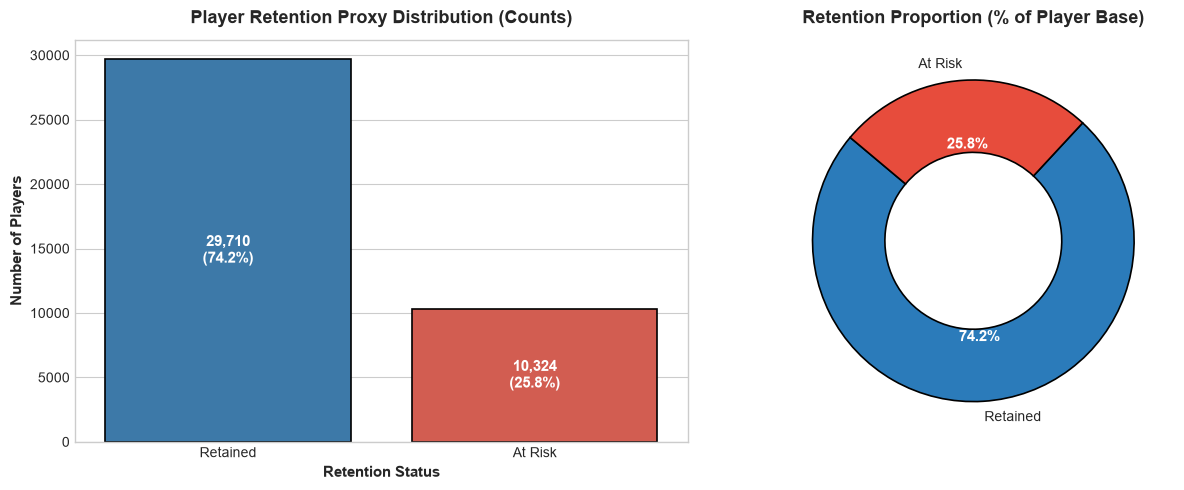

📊 Saved: outputs/retention_distribution.png


/var/folders/qy/q2lr7b053z394dkb015mn1ym0000gn/T/ipykernel_7618/119686410.py:55: UserWarning: Glyph 8627 (\N{DOWNWARDS ARROW WITH TIP RIGHTWARDS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/qy/q2lr7b053z394dkb015mn1ym0000gn/T/ipykernel_7618/119686410.py:57: UserWarning: Glyph 8627 (\N{DOWNWARDS ARROW WITH TIP RIGHTWARDS}) missing from font(s) Arial.
  fig.savefig(eng_dist_path, dpi=300, bbox_inches='tight')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8627 (\N{DOWNWARDS ARROW WITH TIP RIGHTWARDS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


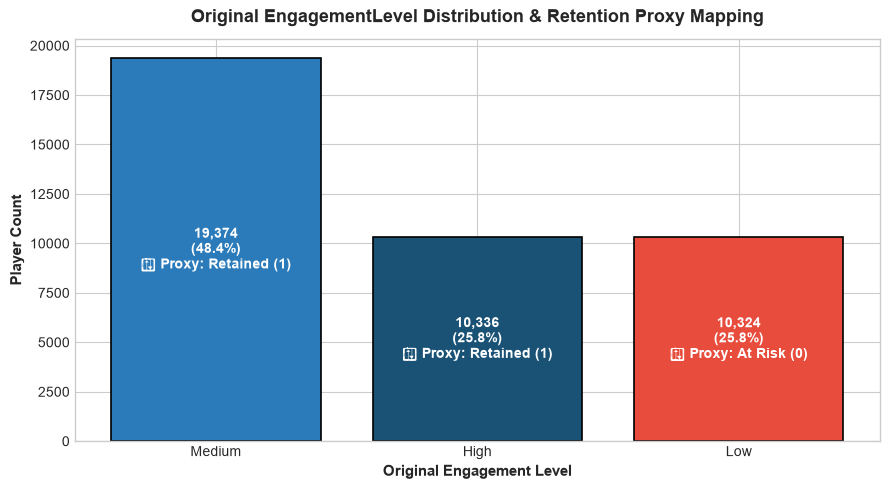

📊 Saved: outputs/engagement_level_distribution.png


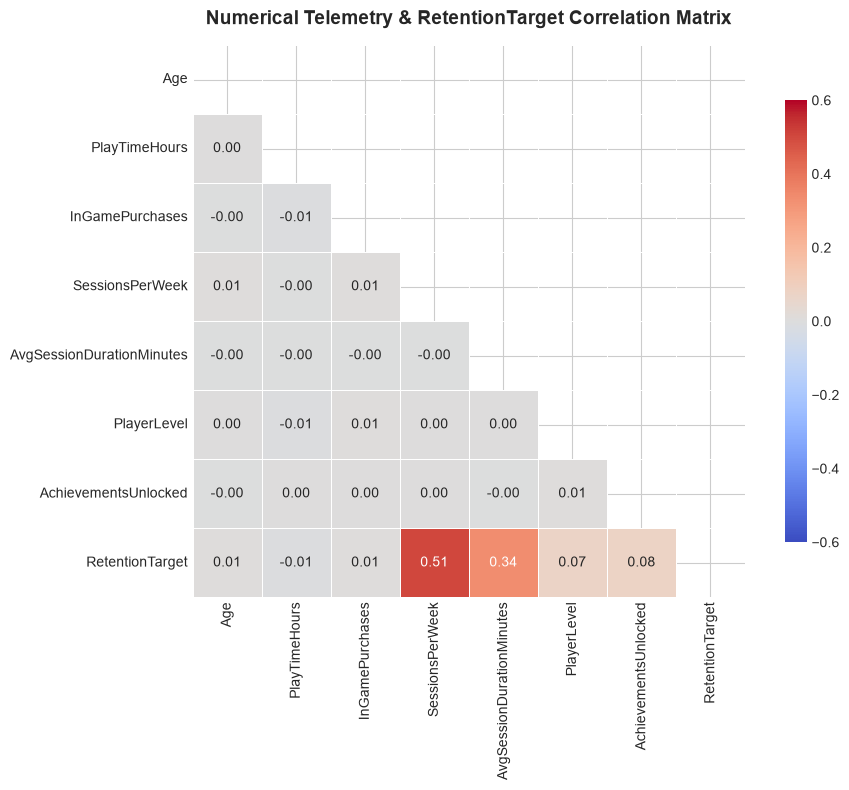

📊 Saved: outputs/correlation_heatmap.png


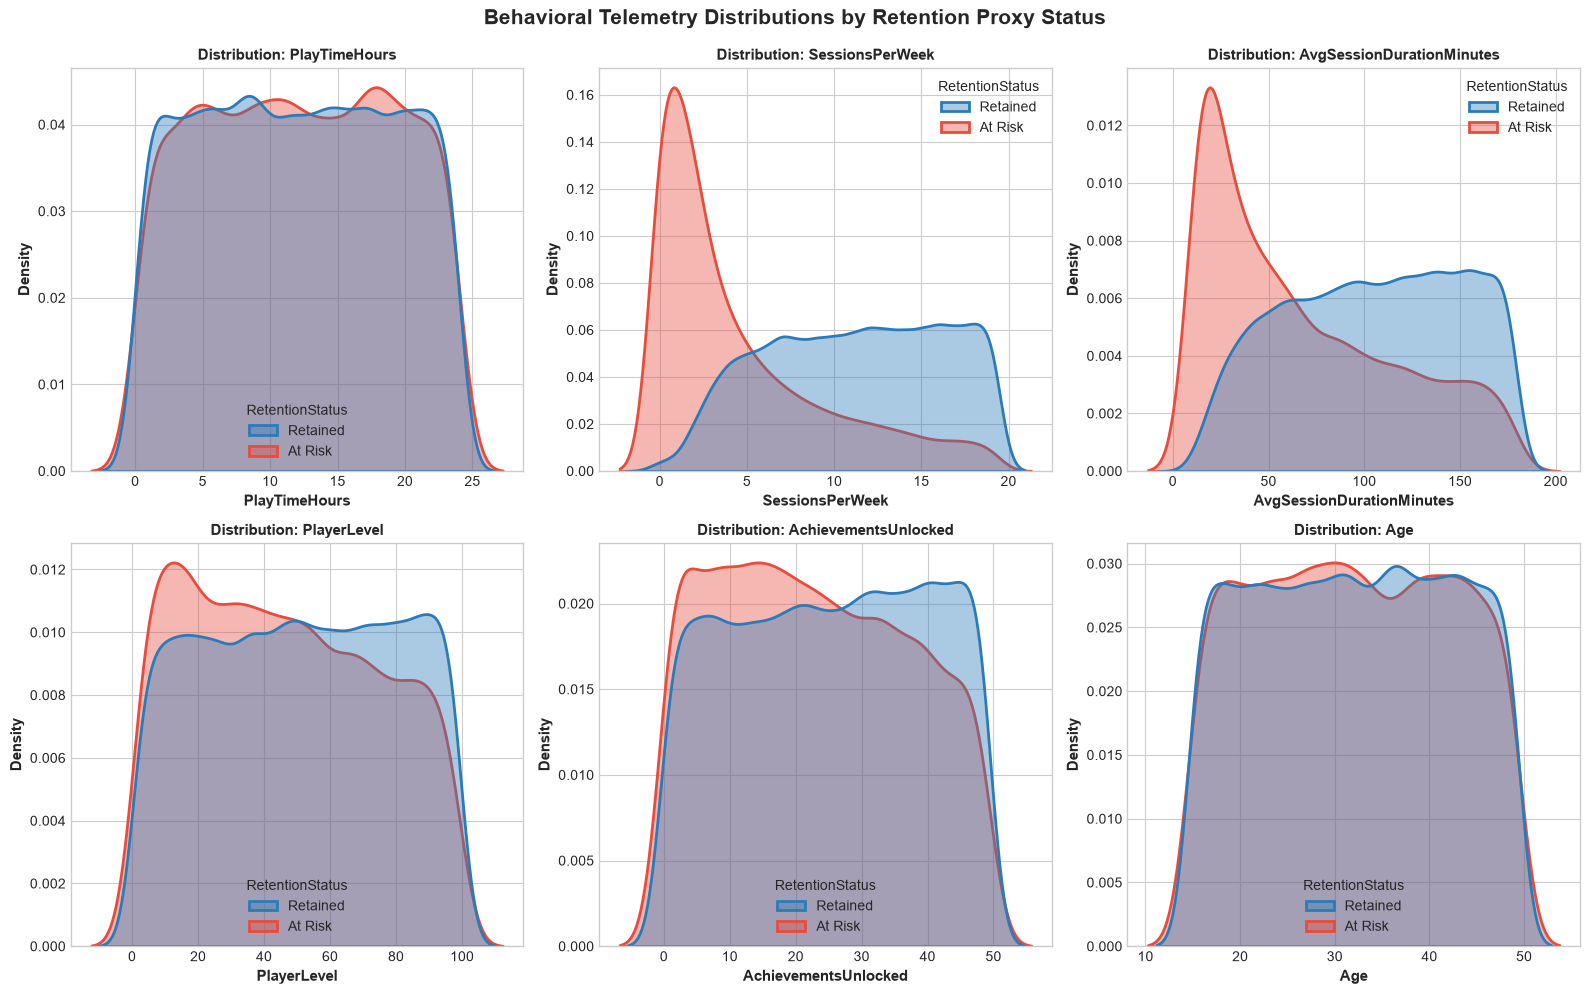

📊 Saved: outputs/behavioral_feature_distributions.png


In [8]:
# ==============================================================================
# 7. VISUALIZATIONS & OUTPUT ARTIFACT EXPORT
# ==============================================================================

# Palette setup
palette = {'Retained': '#2b7bba', 'At Risk': '#e74c3c'}

# ------------------------------------------------------------------------------
# 1. Retention Distribution Figure
# ------------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Count barplot
sns.barplot(x=status_counts.index, y=status_counts.values, palette=palette, ax=ax1, edgecolor='black', linewidth=1.2)
ax1.set_title("Player Retention Proxy Distribution (Counts)", fontsize=13, weight='bold', pad=12)
ax1.set_xlabel("Retention Status", weight='semibold')
ax1.set_ylabel("Number of Players", weight='semibold')
for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height()):,}\n({p.get_height()/len(df)*100:.1f}%)",
                 (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                 ha='center', va='center', color='white', weight='bold', fontsize=11)

# Donut chart
wedges, texts, autotexts = ax2.pie(
    status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
    startangle=140, colors=[palette[k] for k in status_counts.index],
    wedgeprops=dict(width=0.45, edgecolor='black', linewidth=1.2)
)
plt.setp(autotexts, size=11, weight="bold", color="white")
ax2.set_title("Retention Proportion (% of Player Base)", fontsize=13, weight='bold', pad=12)

plt.tight_layout()
retention_dist_path = OUTPUTS_DIR / "retention_distribution.png"
fig.savefig(retention_dist_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"📊 Saved: {retention_dist_path}")

# ------------------------------------------------------------------------------
# 2. EngagementLevel Mapping Figure
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
eng_counts = df['EngagementLevel'].value_counts()
eng_colors = {'Medium': '#2b7bba', 'High': '#1a5276', 'Low': '#e74c3c'}
bars = ax.bar(eng_counts.index, eng_counts.values, color=[eng_colors[k] for k in eng_counts.index], edgecolor='black', linewidth=1.2)
ax.set_title("Original EngagementLevel Distribution & Retention Proxy Mapping", fontsize=13, weight='bold', pad=12)
ax.set_xlabel("Original Engagement Level", weight='semibold')
ax.set_ylabel("Player Count", weight='semibold')

for bar, (level, count) in zip(bars, eng_counts.items()):
    proxy = "Retained (1)" if level in ['Medium', 'High'] else "At Risk (0)"
    ax.annotate(f"{count:,}\n({count/len(df)*100:.1f}%)\n↳ Proxy: {proxy}",
                (bar.get_x() + bar.get_width() / 2., bar.get_height() / 2),
                ha='center', va='center', color='white', weight='bold', fontsize=10)

plt.tight_layout()
eng_dist_path = OUTPUTS_DIR / "engagement_level_distribution.png"
fig.savefig(eng_dist_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"📊 Saved: {eng_dist_path}")

# ------------------------------------------------------------------------------
# 3. Correlation Heatmap
# ------------------------------------------------------------------------------
corr_cols = numerical_features + ['RetentionTarget']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
    vmin=-0.6, vmax=0.6, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax
)
ax.set_title("Numerical Telemetry & RetentionTarget Correlation Matrix", fontsize=14, weight='bold', pad=15)
plt.tight_layout()
corr_path = OUTPUTS_DIR / "correlation_heatmap.png"
fig.savefig(corr_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"📊 Saved: {corr_path}")

# ------------------------------------------------------------------------------
# 4. Behavioral Feature Distributions by Retention Status
# ------------------------------------------------------------------------------
key_behavioral = ['PlayTimeHours', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'Age']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_behavioral):
    sns.kdeplot(
        data=df, x=col, hue='RetentionStatus', common_norm=False, fill=True,
        palette=palette, alpha=0.4, linewidth=2, ax=axes[i]
    )
    axes[i].set_title(f"Distribution: {col}", weight='bold', fontsize=11)
    axes[i].set_xlabel(col, weight='semibold')
    axes[i].set_ylabel("Density", weight='semibold')

plt.suptitle("Behavioral Telemetry Distributions by Retention Proxy Status", fontsize=15, weight='bold', y=0.99)
plt.tight_layout()
behav_path = OUTPUTS_DIR / "behavioral_feature_distributions.png"
fig.savefig(behav_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"📊 Saved: {behav_path}")

### 8. Summary of Phase 2 Outcomes & College Viva Defense Guide

#### Summary of Preprocessing Specifications:
- **Discovered Source Data:** `online_gaming_behavior_dataset.csv` (40,034 instances, 13 features).
- **Target Construction:** Operational proxy `RetentionTarget` mapped from `EngagementLevel` (`1` = Retained, `0` = At Risk).
- **Leakage Prevention:** `PlayerID`, `EngagementLevel`, and `RetentionStatus` isolated completely from $X$.
- **Partitioning:** Stratified 80/20 train/test split:
  - $X_{train}$: $32,027$ samples
  - $X_{test}$: $8,007$ samples
- **Pipeline Encoding:** `ColumnTransformer` with median/mode imputation, standard scaling, and one-hot encoding yielding $21$ engineered feature dimensions.

---
#### Viva Defense Preparation Questions & Answers:
1. **Q: Why create an operational retention proxy instead of using actual churn data?**
   - **A:** The benchmark dataset provides an aggregated engagement tier (`EngagementLevel`) rather than multi-week time-series churn labels. In industry analytics, engagement tiers serve as standard retention proxies because high/medium engagement signifies continuous active usage, whereas low engagement indicates imminent churn. Explicitly noting this methodology demonstrates scientific rigor and academic honesty.
2. **Q: Why was `EngagementLevel` excluded from the feature matrix?**
   - **A:** Including `EngagementLevel` would represent fatal *target leakage* because the target `RetentionTarget` was directly mathematically derived from it. A model trained with `EngagementLevel` would learn a trivial tautology rather than genuine behavioral drivers.
3. **Q: Why use `ColumnTransformer` fitted only on training data?**
   - **A:** Fitting scalers and encoders on the entire dataset leaks global summary statistics (mean, variance, category frequencies) from the test set into training, inflating cross-validation performance. Fitting strictly on `X_train` guarantees strict separation and realistic generalization estimates.
